# Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import correlate
from hapi import *
from pylab import plot
# from bin_spec import bin_spectrum
import seaborn as sns

os.chdir('/Users/zaniaccollins/Research/SGL/sgl_science_case/')
from bin_spec import bin_spectrum

%matplotlib widget

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

# Configuration

In [2]:
DATA_DIR = "/Users/zaniaccollins/Research/SGL/sgl_science_case/data"
hapi_data_dir = "HAPI_DB"
atmospheric_profile_path = "/Users/zaniaccollins/Research/SGL/sgl_science_case/data/external/atmosphere_profile.csv"

db_begin('/Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB')

Using /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB

CH4


                     Lines parsed: 2946
CH4_iso2
                     Lines parsed: 11300
H2O_iso3
                     Lines parsed: 763
N2_iso1
                     Lines parsed: 24
H2O_iso1
                     Lines parsed: 2120
CH4_iso1
                     Lines parsed: 21535
H2O_main
                     Lines parsed: 1123
CH4_iso3
                     Lines parsed: 962
N2O_iso1
                     Lines parsed: 16617
H2O
                     Lines parsed: 15602
H2O_iso2
                     Lines parsed: 983


# User parameters

In [3]:
wl_min = 7.0
wl_max = 8.5
native_dwn = 0.001     # cm^-1, native HITRAN-resolution sampling (HAPI side)

wn_min = 1e4/wl_max
wn_max = 1e4/wl_min


In [4]:
df_atmospheric_profile_table = pd.read_csv(atmospheric_profile_path)

# Helper Functions

In [5]:
kB = 1.380649e-23  # Boltzmann constant, J/K

def get_molecule_id(molecule_name):
    """Return (M, common_local_I) for a molecule by name"""
    for (M, I), data in hapi.ISO.items():
        if data[4].upper() == molecule_name.upper():   # data[4] is the molecule name like 'N2O'
            return M, I   # returns first (main) isotopologue
    raise ValueError(f"Molecule {molecule_name} not found in hapi.ISO")

def compute_absorption_coefficient(molecule, isotope, dwn, altitude):
    """Compute absorption coefficient (cm^-1) for pure gas at layer conditions."""
    print(f"Computing coef for {molecule} iso{isotope} at alt {altitude}")
    M, __ = get_molecule_id(molecule)
    
    table_name = f"{molecule}_iso{isotope}"
    
    p_atm = df_atmospheric_profile_table["PRES_mb"].iloc[altitude] / 1013.25
    vmr = df_atmospheric_profile_table[f"{molecule}_ppmv"].iloc[altitude] / 1e6

    wn_grid, coef = absorptionCoefficient_Voigt(
        Components=[(M, isotope, vmr)],  # pure gas -> scale by vmr later
        Diluent={'self': vmr, 'air': 1.0 - vmr},
        SourceTables=table_name,
        WavenumberRange=(wn_min, wn_max),
        WavenumberStep=dwn,
        Environment={
            'T': df_atmospheric_profile_table["TEMP_K"].iloc[altitude], 
            'p': p_atm # Convert from mb to atmospheres
        },
        HITRAN_units=False  # Get absorption coefficient in cm^-1
    )
    return wn_grid, coef

def compute_reflectivity(molecules_isotopes, dwn, cloud_top = 8.0, albedo = 0.3): #cloud_top is in km
    '''
    Input: tuple list?: [(molecule, isotopes), ...], dwn, cloud_top (km), albedo

    computes intensity across wavelength for earth-like atmosphere

    Output: wavelengths_µm (array), transmission (array), wn_grid_ref (array)
    '''

    alt_df = df_atmospheric_profile_table.copy().reset_index(drop=True)
    
    # Layers above the cloud deck
    above_cloud_mask = alt_df["ALT_km"] >= cloud_top
    above_df = alt_df[above_cloud_mask].reset_index(drop=True)
    
    print(f"Computing reflectivity above cloud top at {cloud_top} km ({len(above_df)} layers)")
    
    alt_km = above_df["ALT_km"].values
    dz_km = np.diff(alt_km, append=alt_km[-1] + np.median(np.diff(alt_km)))
    dz_cm = dz_km * 1e5
    
    #temporary debug:
    # dz_cm *= 0.1

    total_tau = None
    wn_grid_ref = None
    
    for mol, iso in molecules_isotopes:
        col_name = f"{mol}_ppmv"   # <--- exact match to CSV
        print(f"Looking for column: {col_name}")
        if col_name not in alt_df.columns:
            print("ERROR: Column not found! Using available VMR-like columns:", [c for c in alt_df.columns if 'ppm' in c.lower() or 'vmr' in c.lower()])
            continue
            
        print(f"→ Processing {mol} iso{iso}")
        for i, row in above_df.iterrows():
            wn_grid, coef_pure = compute_absorption_coefficient(mol, iso, dwn, i)
            if wn_grid_ref is None:
                wn_grid_ref = wn_grid.copy()
            
            ppmv = float(row[col_name])
            vmr = ppmv * 1e-6

            if mol == 'H2O':
                vmr *= 1e-2
            if mol == 'N2O':
                vmr *= 8
            
            delta_tau = coef_pure * vmr * dz_cm[i]
            
            if total_tau is None:
                total_tau = np.zeros_like(coef_pure)
            total_tau += delta_tau
            
            # if i % 15 == 0:
            #     print(f"  Layer {alt_km[i]:5.1f} km | ppmv={ppmv:8.2f} | vmr={vmr:.2e} | max_delta_tau={np.max(delta_tau):.2e} | cum_max_tau={np.max(total_tau):.2e}")
    
    if total_tau is None:
        raise ValueError("No tau accumulated")
    
    total_tau_roundtrip = 2*total_tau
    
    print(f"\nFINAL: max_tau_roundtrip = {np.max(total_tau_roundtrip):.2f}, mean_tau = {np.mean(total_tau_roundtrip):.2f}")
    transmission_roundtrip = np.exp(-total_tau_roundtrip)
    print(f"Transmission range: {transmission_roundtrip.min():.6f} to {transmission_roundtrip.max():.6f}")

    reflectivity = albedo * transmission_roundtrip
    
    wavelengths_um = 1e4 / wn_grid_ref
    return wavelengths_um, transmission_roundtrip

def generate_res_dict(molecule_scenarios, resolutions, snrs=None, cloud_top=8.0, albedo=0.3):
    """
    molecule_scenarios: list of lists like [[('H2O', 1)], [('CO2', 1)], [('CH4',1), ('N2O',1)]]
    resolutions: list of R values (e.g. [100, 500, 1000])
    snrs: list of SNRs to inject noise for (e.g. [50, 100, 200]). If None, only clean spectra.
    """
    if snrs is None:
        snrs = []
    
    res_dict = {}
    
    for scenario in molecule_scenarios:
        # Create a nice scenario key (e.g. 'H2O', 'CH4+N2O')
        if len(scenario) == 1:
            scenario_key = scenario[0][0]
        else:
            scenario_key = '+'.join([mol for mol, iso in scenario])
        
        print(f"Computing high-res for scenario: {scenario_key}")
        
        # Compute once at very high resolution
        wl_high, refl_high = compute_reflectivity(
            scenario, 
            dwn=0.001, 
            cloud_top=cloud_top, 
            albedo=albedo
        )
        
        print(f"  High-res grid size: {len(wl_high)} points")
        
        for R in resolutions:
            res_key = int(R)
            
            if res_key not in res_dict:
                res_dict[res_key] = {}
            
            # Bin the clean spectrum
            wl_binned, refl_binned, _ = bin_spectrum(wl_high, refl_high, R)
            
            entry = {
                'wavelength_grid': wl_binned,
                'reflectivity_clean': refl_binned,
                'resolution': res_key,
            }
            
            # Add noisy versions for each SNR
            for snr in snrs:
                noisy, errors = inject_poisson_noise(refl_binned, snr=snr)
                entry[f'reflectivity_snr{snr}'] = noisy
                entry[f'error_snr{snr}'] = errors
            
            res_dict[res_key][scenario_key] = entry
    
    return res_dict

def inject_poisson_noise(trans, snr, seed=42, mode='gaussian_approx'):

    """
    Inject noise into a transmission or reflectivity spectrum.
    
    Parameters:
        signal: array of transmission or reflectivity (0 to 1)
        snr: desired signal-to-noise ratio (scalar or per-bin array)
        mode: 'gaussian_approx' (recommended) or 'true_poisson'
    """
    np.random.seed(seed)
    
    signal = 1 - trans

    if mode == 'gaussian_approx':
        # Most common approach for spectra
        noise_std = signal / snr          # relative noise
        noise = np.random.normal(0, noise_std)
        noisy = trans + noise
        errorbars = noise_std
        
    elif mode == 'true_poisson':
        # True Poisson if you have absolute photon counts
        # Assume max_signal corresponds to e.g. 1e6 photons
        max_counts = 1e9                   # SGL high photon count!!
        counts = signal * max_counts
        noisy_counts = np.random.poisson(counts)
        noisy = noisy_counts / max_counts 
        errorbars = np.sqrt(counts) / max_counts   # sqrt(N) / N0
    
    else:
        raise ValueError("mode must be 'gaussian_approx' or 'true_poisson'")
    
    # Clip to physical range
    noisy = np.clip(noisy, 0.0, 1.0)
    
    return noisy, errorbars

def cross_correlate_spectra(template_spectra, test_spectra, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation between two spectra.
    
    Returns a dictionary with all relevant results.
    """
    # Zero-mean normalization
    template_norm = (template_spectra - np.mean(template_spectra)) / np.std(template_spectra)
    test_norm     = (test_spectra     - np.mean(test_spectra))     / np.std(test_spectra)
    
    # Cross-correlation
    ccf = correlate(template_norm, test_norm, mode='full')
    ccf /= np.sqrt(np.sum(template_norm**2) * np.sum(test_norm**2))
    
    # Lags
    if lags is None:
        lags = np.arange(-len(template_norm) + 1, len(template_norm))
    
    # Basic statistics
    max_corr = np.max(ccf)
    peak_idx = np.argmax(ccf)
    
    # Noise estimation from wings (excluding central peak)
    window_size = int(0.15 * len(ccf))
    noise_mask = np.ones(len(ccf), dtype=bool)
    noise_mask[max(0, peak_idx - window_size): min(len(ccf), peak_idx + window_size)] = False
    noise_values = ccf[noise_mask]
    noise_std = np.std(noise_values) if len(noise_values) > 20 else np.std(ccf)
    
    # SNR array
    cc_snr = ccf / noise_std if noise_std > 0 else np.zeros_like(ccf)
    
    results = {
        'ccf': ccf,
        'lags': lags,
        'max_correlation': max_corr,
        'peak_lag': lags[peak_idx],
        'noise_std': noise_std,
        'cc_snr': cc_snr,
        'template_norm': template_norm,
        'test_norm': test_norm,
    }
    
    if return_full:
        results['ccf_clean'] = np.clip(np.nan_to_num(ccf, nan=0.0), 0, None)
    
    return results

def cross_correlate_spectra_in_dict(parent_dict, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation for all scenarios in input spectral dictionary
    
    Returns a dictionary with all relevant results.
    """

    records = []

    for r, res_data in parent_dict.items():
        for scen_template in res_data:
            clean_key = 'reflectivity_clean'
            if clean_key not in res_data[scen_template]:
                continue

            template_spectra = res_data[scen_template][clean_key]

            for scen_test in res_data:
                for key in list(res_data[scen_test].keys()):
                    if not key.startswith('reflectivity_snr'):
                        continue

                    noisy_spectra = res_data[scen_test][key]
                    snr_value = key.split('snr')[-1]

                    if len(template_spectra) != len(noisy_spectra):
                        continue

                    results = cross_correlate_spectra(template_spectra, noisy_spectra)

                    records.append({
                        'resolution': r,
                        'template_scenario': scen_template,
                        'test_scenario': scen_test,
                        'snr': int(snr_value),
                        'max_correlation': results['max_correlation'],
                        'cc_snr_max': np.max(results['cc_snr']),
                        'peak_lag': results['peak_lag'],
                        'noise_std': results['noise_std'],
                        'ccf': results['ccf'],
                        'lags': results['lags']
                    })
    df = pd.DataFrame(records)
    print(f"Generated {len(df)} cross-correlation records")
    return df


# Test - Earth T-P Profile ✅

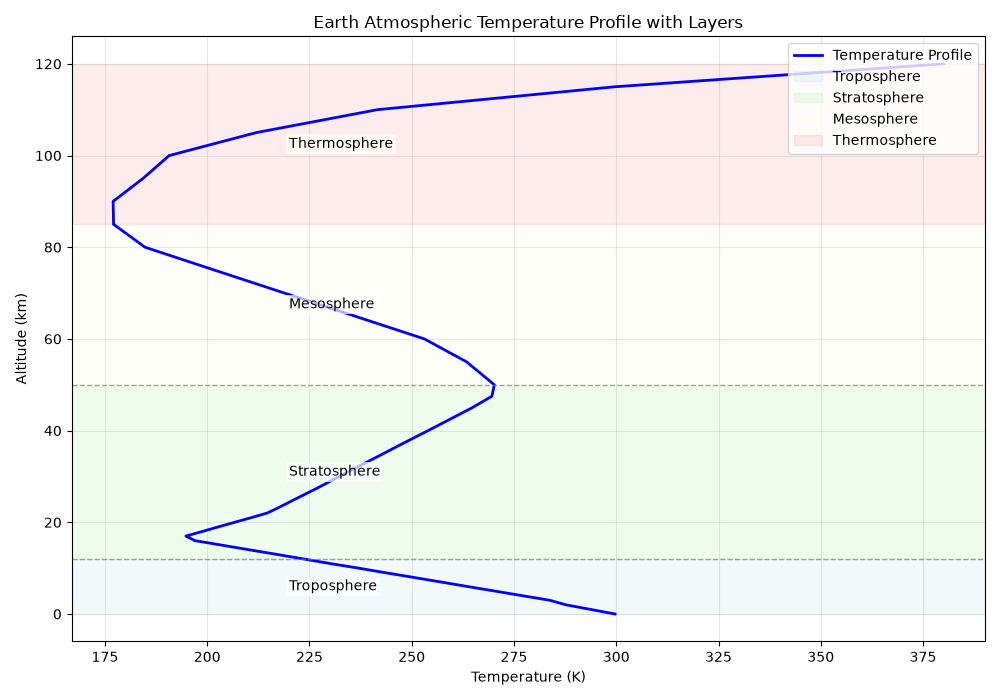

In [57]:
plt.figure(figsize=(10, 7))

# Main temperature profile
plt.plot(df_atmospheric_profile_table["TEMP_K"], 
         df_atmospheric_profile_table["ALT_km"], 
         color='blue', linewidth=2, label='Temperature Profile')

# Standard atmospheric layer boundaries (approximate)
layers = [
    (0, 12, "Troposphere", "lightblue"),
    (12, 50, "Stratosphere", "lightgreen"),
    (50, 85, "Mesosphere", "lightyellow"),
    (85, 120, "Thermosphere", "lightcoral")
]

for bottom, top, name, color in layers:
    plt.axhspan(bottom, top, alpha=0.15, color=color, label=name)
    # Label in the middle of the layer
    mid = (bottom + top) / 2
    plt.text(220, mid, name, fontsize=10, va='center', ha='left', 
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

plt.xlabel("Temperature (K)")
plt.ylabel("Altitude (km)")
plt.title("Earth Atmospheric Temperature Profile with Layers")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

# Optional: mark tropopause etc.
plt.axhline(12, color='gray', linestyle='--', alpha=0.7, linewidth=1)
plt.axhline(50, color='gray', linestyle='--', alpha=0.7, linewidth=1)

plt.tight_layout()
plt.show()

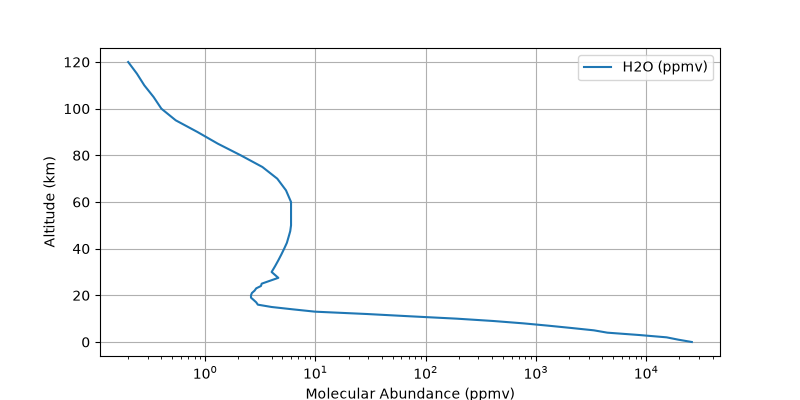

In [58]:
# Plotting molecular abundance profiles 

plt.figure(figsize=(8, 4))
plt.plot(df_atmospheric_profile_table["H2O_ppmv"], df_atmospheric_profile_table["ALT_km"], label="H2O (ppmv)")
# plt.plot( df_atmospheric_profile_table["ALT_km"], df_atmospheric_profile_table["CH4_ppmv"], label="CH4 (ppmv)")
# plt.plot(df_atmospheric_profile_table["ALT_km"], df_atmospheric_profile_table["O3_ppmv"], label="O3 (ppmv)")
# plt.plot(df_atmospheric_profile_table["ALT_km"], df_atmospheric_profile_table["N2O_ppmv"], label="N2O (ppmv)")
plt.xscale("log")
plt.xlabel("Molecular Abundance (ppmv)")
plt.ylabel("Altitude (km)")
plt.grid(True)
plt.legend()
plt.show()

# Test Reflectivity Spectra - ✅

In [ ]:
# Example
mols = [('H2O', 1)]  # adjust isotopes

# Downloading table with correct wn_min and wn_max:

# for mol, isotope in mols:
#     M, _ = get_molecule_id(mol)
#     table_name = f'{mol}_iso{isotope}'
#     fetch(table_name,M,isotope,wn_min,wn_max)

alts =  range(len(df_atmospheric_profile_table))  # or subset

wl, trans = compute_reflectivity(mols, dwn=0.01, cloud_top= 1)


Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O_iso1
  65536 bytes written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.data
  65536 bytes written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.data
  65536 bytes written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.data
  65536 bytes written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.data
  65536 bytes written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.data
  65536 bytes written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.data
Header written to /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB/H2O_iso1.header
END DOWNLOAD
                     Lines parsed: 2120
PROCESSED
Computing reflectivity above cloud top at 1 km (49 layers)
Looking for column: H2O_ppmv
→ Processing H2O iso1
Computing 

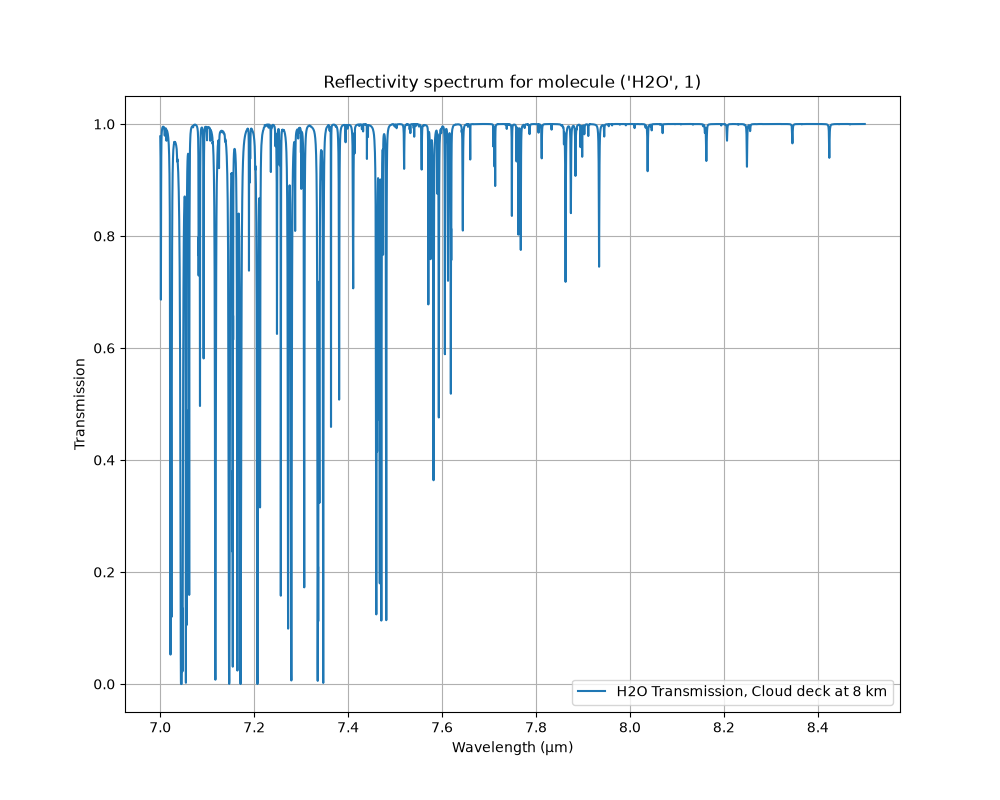

In [21]:
plt.figure(figsize=(10, 8))
plt.title(f"Reflectivity spectrum for molecule {mols[0]}")
plt.plot(wl, trans, label=f"{mols[0][0]} Transmission, Cloud deck at {8} km")
plt.xlabel("Wavelength (μm)")
plt.ylabel("Transmission")
# plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
snr = 10
noisy_trans, errors = inject_poisson_noise(trans, snr, mode='gaussian_approx')

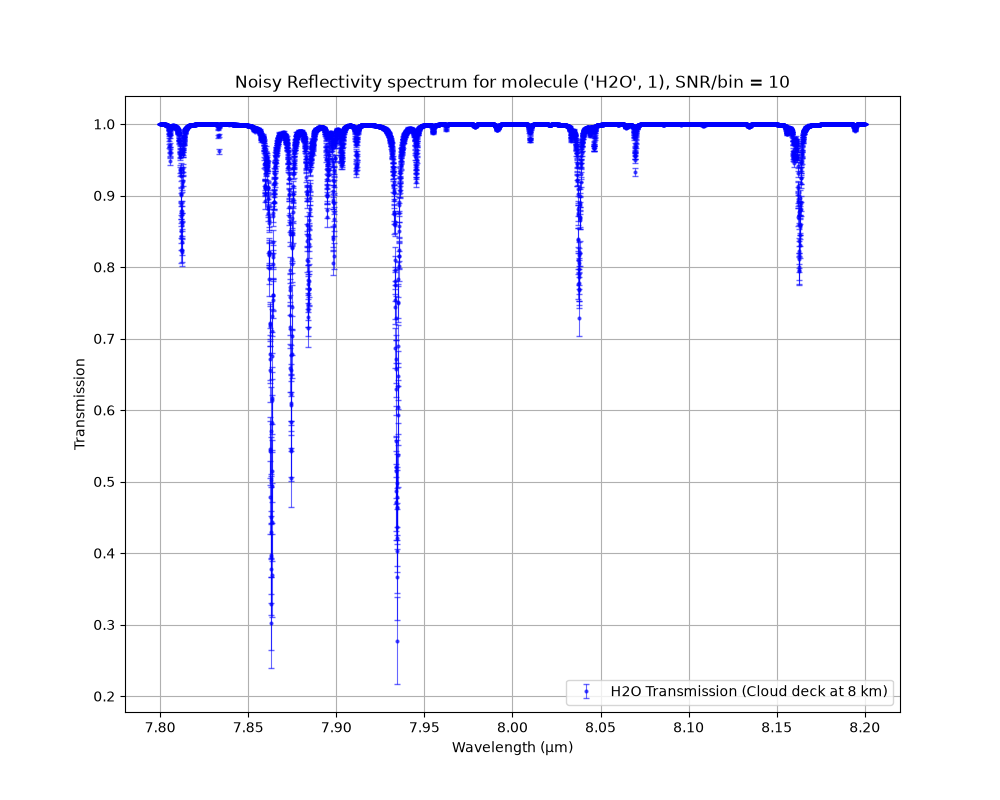

In [ ]:
plt.figure(figsize=(10, 8))
plt.title(f"Noisy Reflectivity spectrum for molecule {mols[0]}, SNR/bin = {snr}")
plt.errorbar(wl, noisy_trans, yerr=errors, fmt='o', markersize=2, 
             color='blue', ecolor='blue', elinewidth=0.8, capsize=2, 
             alpha=0.6, label=f"{mols[0][0]} Transmission (Cloud deck at 8 km)")
plt.xlabel("Wavelength (μm)")
plt.ylabel("Transmission")
# plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

# Dictionary generation test ✅

In [ ]:
# scenarios = [[('H2O', 1)], [('CH4', 1)], [('N2O', 1)], [('H2O', 1), ('CH4', 1), ('N2O', 1)],[('H2O', 1), ('CH4', 1)], [('CH4', 1), ('N2O', 1)], [('H2O', 1), ('N2O', 1)]]


# # # recreating tables with correct wvenumber range
# # mols = [('H2O', 1), ('CH4', 1), ('N2O', 1)]
# # for mol, isotope in mols:
# #     M, _ = get_molecule_id(mol)
# #     table_name = f'{mol}_iso{isotope}'
# #     fetch(table_name,M,isotope,wn_min,wn_max)
    

# resolutions = [500, 1000, 5000, 10000, 100000, 1e6]
# snrs = [5, 10, 20, 30, 40, 50]

# res_dict = generate_res_dict(scenarios, resolutions, snrs, cloud_top=15.0, albedo=0.3)

Computing high-res for scenario: H2O
Computing reflectivity above cloud top at 15.0 km (35 layers)
Looking for column: H2O_ppmv
→ Processing H2O iso1
Computing coef for H2O iso1 at alt 0
{'self': np.float64(0.0259), 'air': np.float64(0.9741)}
1.569868 seconds elapsed for abscoef; nlines = 2120
Computing coef for H2O iso1 at alt 1
{'self': np.float64(0.0195), 'air': np.float64(0.9805)}
1.468922 seconds elapsed for abscoef; nlines = 2120
Computing coef for H2O iso1 at alt 2
{'self': np.float64(0.0153), 'air': np.float64(0.9847)}
1.428687 seconds elapsed for abscoef; nlines = 2120
Computing coef for H2O iso1 at alt 3
{'self': np.float64(0.0086), 'air': np.float64(0.9914)}
1.560380 seconds elapsed for abscoef; nlines = 2120
Computing coef for H2O iso1 at alt 4
{'self': np.float64(0.00444), 'air': np.float64(0.99556)}
1.677000 seconds elapsed for abscoef; nlines = 2120
Computing coef for H2O iso1 at alt 5
{'self': np.float64(0.00335), 'air': np.float64(0.99665)}
2.083125 seconds elapsed for

In [ ]:
# import pickle
# import gzip   # for compression (highly recommended for large dicts)

# # Save with compression
# with gzip.open("res_dict_large.pkl.gz", "wb") as f:
#     pickle.dump(res_dict, f)

# print("Saved to res_dict_large.pkl.gz")

Saved to res_dict_large.pkl.gz


In [7]:
plt.close('all')

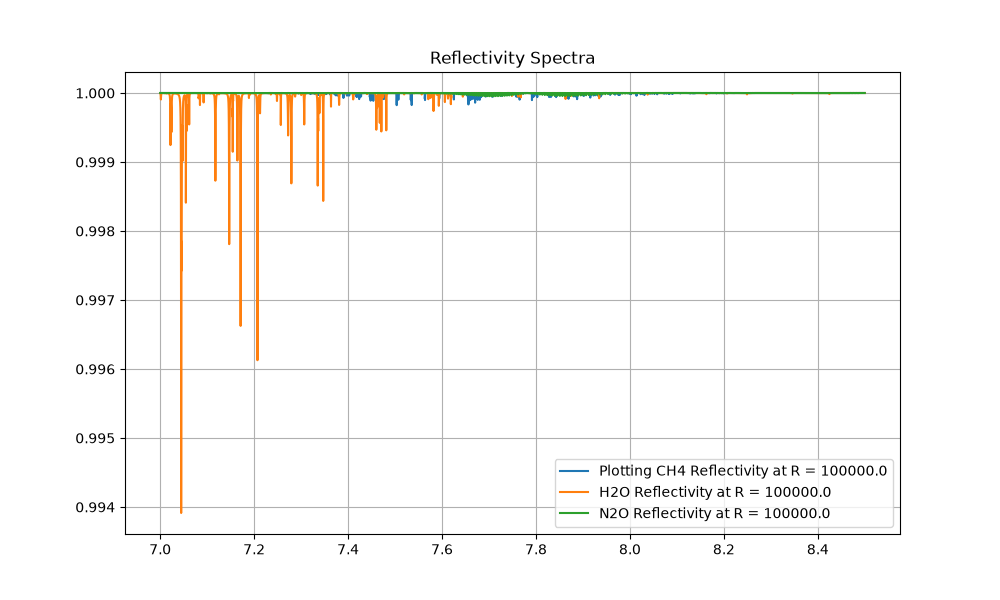

In [14]:
plt.close('all')
plt.figure(figsize=(10,6))


resolution_to_plot = 1e5
scenario_to_plot = 'CH4'
snr_to_plot = 50
clean_plot = True

data = res_dict[resolution_to_plot][scenario_to_plot]
data_temp = res_dict[resolution_to_plot]['H2O']
data_temp2 = res_dict[resolution_to_plot]['N2O']

if clean_plot:
    plt.plot(data['wavelength_grid'], data['reflectivity_clean'], label = f'Plotting {scenario_to_plot} Reflectivity at R = {resolution_to_plot}')

else:
    plt.plot(data['wavelength_grid'], data[f'reflectivity_snr{snr_to_plot}'], label = f'{scenario_to_plot} Reflectivity at R = {resolution_to_plot}, SNR = {snr_to_plot}')

plt.plot(data_temp['wavelength_grid'], data_temp['reflectivity_clean'], label = f'H2O Reflectivity at R = {resolution_to_plot}')
plt.plot(data_temp['wavelength_grid'], data_temp2['reflectivity_clean'], label = f'N2O Reflectivity at R = {resolution_to_plot}')


plt.title('Reflectivity Spectra')
plt.grid()
plt.legend()
plt.show()

# Cross Correlation Tests

In [ ]:
plt.close('all')
df_cc = cross_correlate_spectra_in_dict(res_dict)
template_A = 'CH4+N2O'
template_B = 'H2O+CH4+N2O' 
test_scen = 'H2O+CH4+N2O'

df_A = df_cc[(df_cc['template_scenario'] == template_A) & (df_cc['test_scenario'] == test_scen)].copy()
df_B = df_cc[(df_cc['template_scenario'] == template_B) & (df_cc['test_scenario'] == test_scen)].copy()

print("Rows A:", len(df_A), "Rows B:", len(df_B))

Generated 1764 cross-correlation records
Rows A: 36 Rows B: 36


In [55]:
merged = pd.merge(df_A, df_B, on=['resolution', 'snr'], suffixes=('_A', '_B'))

merged['delta'] = merged['max_correlation_A'] - merged['max_correlation_B']
merged['difference'] = merged['ccf_A'] - merged['ccf_B']   # array subtraction


def compute_difference_stats(row):
    diff = row['difference']
    if not isinstance(diff, np.ndarray):
        diff = np.array(diff)
    
    peak_idx = (len(diff)-1)//2#np.argmax(np.abs(diff))
    # print(len(diff))
    # print(peak_idx)
    peak_diff = diff[peak_idx]
    
    length = len(diff)
    window = int(0.15 * length)
    noise_mask = np.ones(length, dtype=bool)
    noise_mask[max(0, peak_idx - window): min(length, peak_idx + window)] = False
    
    noise_values = diff[noise_mask]
    noise_std = np.std(noise_values) if len(noise_values) > 10 else np.std(diff)

    # noise_std = np.sqrt(row['noise_std_A']**2+row['noise_std_B']**2)
    
    confidence = peak_diff / noise_std if noise_std > 0 else 0

    # print(f'Standard deviation: {noise_std}, systemic difference: {peak_diff}')
    
    return pd.Series({
        'peak_difference': peak_diff,
        'peak_lag': row['lags'][peak_idx] if 'lags' in row else peak_idx,
        'noise_std': noise_std,
        'difference_confidence': confidence
    })

stats = merged.apply(compute_difference_stats, axis=1)
merged = pd.concat([merged, stats], axis=1)

In [56]:
# # Plot a specific row (example: first one)
# row = merged.iloc[20]

# plt.figure(figsize=(10, 6))
# plt.plot(row['lags_A'], row['difference'], label=f'Difference [{template_A}] - [{template_B}]')
# # plt.plot(row['lags_B'], row['ccf_B'], label='Template B')
# plt.xlabel("Lag")
# plt.ylabel("Delta CCF")
# plt.title("CCF Comparison")
# plt.legend()
# plt.grid(True)
# plt.show()

/var/folders/0y/zn1dltkd6hj_8m8pq81r_98r0000gn/T/ipykernel_7733/1650526308.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,6))


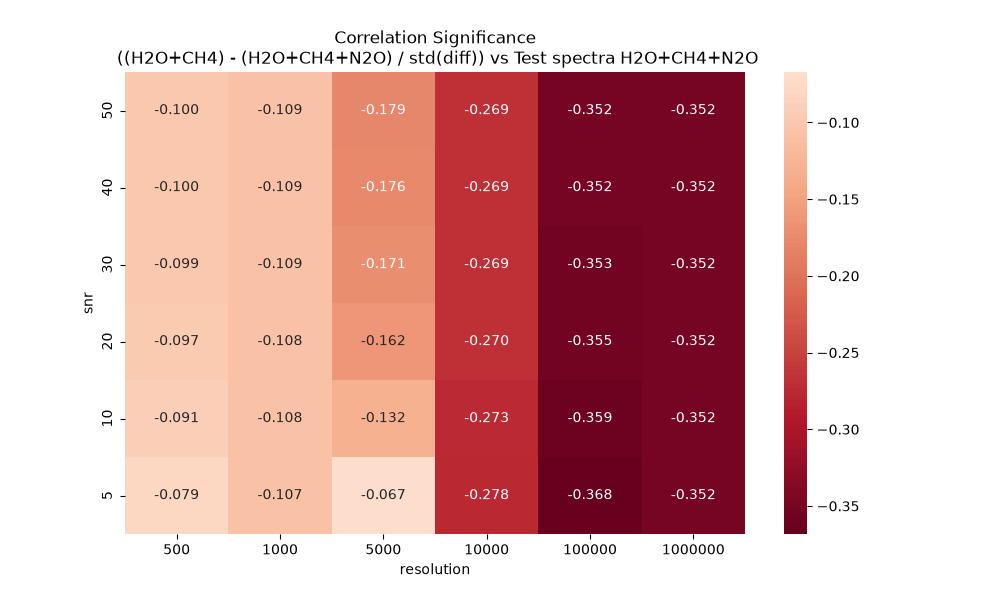

In [58]:
plt.figure(figsize=(10,6))

pivot = merged.pivot_table(index='snr', columns='resolution', values='difference_confidence').sort_index(ascending=False)

sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdBu", center=0)
plt.title(f"Correlation Significance\n (({template_A}) - ({template_B}) / std(diff)) vs Test spectra {test_scen}")

plt.show()